::: {.callout-important}
## The one idea
A Gaussian process is a *distribution over functions*: draw a sample and you get a whole function, not a point. It is specified by a mean function $m(x)$ and a covariance kernel $k(x,x')$, and any finite set of input points has a joint Gaussian distribution.
:::

Start from the familiar multivariate Gaussian and let the dimension grow infinitely.

$$\pmb{y}\sim\mathcal{N}(\pmb\mu,\Sigma),\qquad
P(\pmb{y}) = (2\pi)^{-n/2}|\Sigma|^{-1/2}\exp\!\Big(-\tfrac12(\pmb y-\pmb\mu)^\top\Sigma^{-1}(\pmb y-\pmb\mu)\Big).$$

- A sample from $\mathcal{N}(\pmb\mu,\Sigma)$ is a point in $\mathbb{R}^n$.
- The covariance $\Sigma$ couples the coordinates — here is a correlated 2-D example.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance_matrix

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(0)

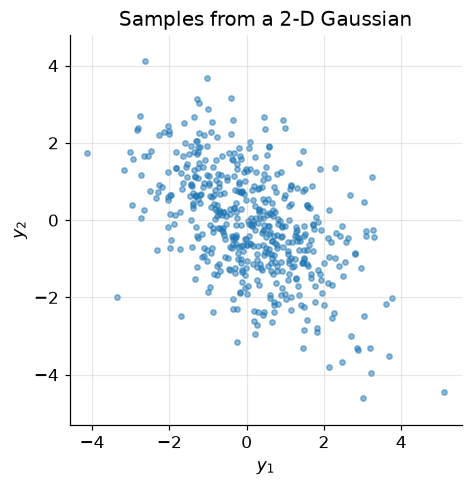

In [2]:
mu = np.array([0.0, 0.0])
Sigma = np.array([[2.0, -1.0], [-1.0, 2.0]])
pts = rng.multivariate_normal(mu, Sigma, 500)

plt.figure(figsize=(4.6, 4.6))
plt.scatter(pts[:, 0], pts[:, 1], s=12, alpha=0.5)
plt.title("Samples from a 2-D Gaussian"); plt.axis("equal")
plt.xlabel("$y_1$"); plt.ylabel("$y_2$")
plt.show()

## 1 · Gaussian processes

- A GP generalizes the multivariate Gaussian from a distribution over *points* to a distribution over *functions* in which each sample is a function.
- It is fully specified by a mean function $m(x)$ and a kernel $k(x,x')$, which determines how correlated the function is at nearby inputs.

A common choice is the radial basis function (RBF, or squared-exponential) kernel:

$$k(x,x') = \sigma^2\exp\!\Big(-\frac{\lVert x-x'\rVert^2}{2\ell^2}\Big).$$

- $\sigma^2$ — output variance (amplitude); $\ell$ — length scale (how fast correlation decays with distance).
- Nearby points are strongly correlated, distant points nearly independent

To draw functions, evaluate the kernel on a grid to form the matrix $K$ and sample $\mathcal{N}(\pmb 0, K)$:

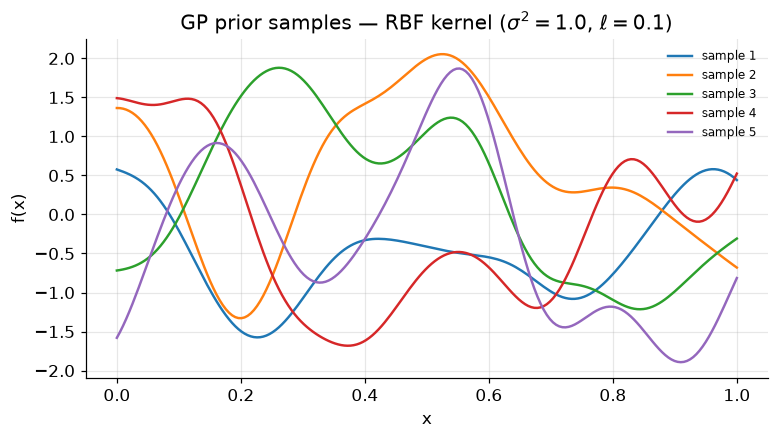

In [3]:
xs = np.linspace(0.0, 1.0, 200)
D = distance_matrix(xs[:, None], xs[:, None])
sigma2, ell = 1.0, 0.1
K = sigma2 * np.exp(-D**2 / (2 * ell**2)) + 1e-9 * np.eye(xs.size)   # jitter for stability

samples = rng.multivariate_normal(np.zeros(xs.size), K, 5)
plt.figure(figsize=(8, 4))
for i, y in enumerate(samples):
    plt.plot(xs, y, lw=1.6, label=f"sample {i+1}")
plt.title(rf"GP prior samples — RBF kernel ($\sigma^2={sigma2}$, $\ell={ell}$)")
plt.xlabel("x"); plt.ylabel("f(x)"); plt.legend(fontsize=8, frameon=False)
plt.show()

### What $m(x)$ and $k(x,x')$ control

- $m(x)$: the mean of the function distribution at each input (here $m\equiv 0$).
- $k(x,x')$: the covariance: it sets both the amplitude and the smoothness of samples.
- Other kernels encode other structure (e.g. periodicity §5).

The two RBF parameters play distinct roles — variance $\sigma^2$ scales amplitude, length scale $\ell$ scales wiggliness:

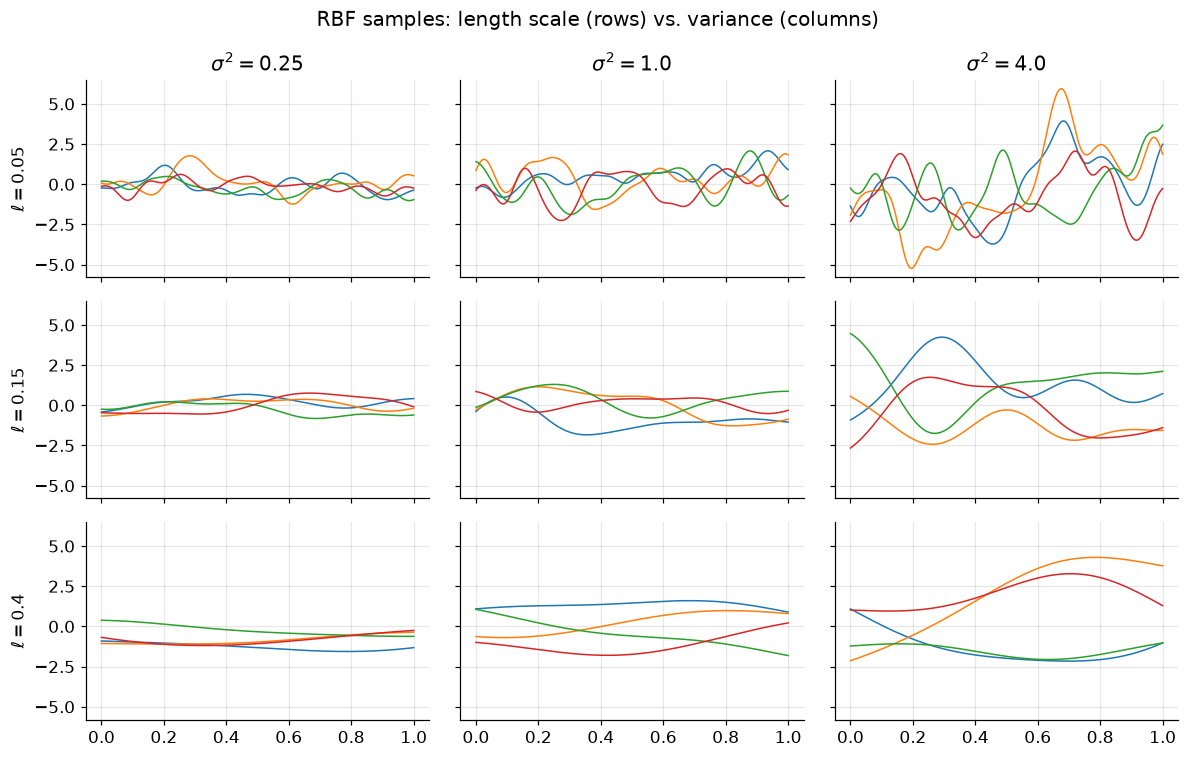

In [4]:
xs = np.linspace(0.0, 1.0, 200)
D = distance_matrix(xs[:, None], xs[:, None])
ells = [0.05, 0.15, 0.4]
sig2s = [0.25, 1.0, 4.0]

fig, axes = plt.subplots(len(ells), len(sig2s), figsize=(11, 7), sharex=True, sharey=True)
for r, ell in enumerate(ells):
    for c, s2 in enumerate(sig2s):
        K = s2 * np.exp(-D**2 / (2 * ell**2)) + 1e-9 * np.eye(xs.size)
        for y in rng.multivariate_normal(np.zeros(xs.size), K, 4):
            axes[r, c].plot(xs, y, lw=1)
        if r == 0: axes[r, c].set_title(rf"$\sigma^2={s2}$")
        if c == 0: axes[r, c].set_ylabel(rf"$\ell={ell}$")
fig.suptitle("RBF samples: length scale (rows) vs. variance (columns)")
plt.tight_layout(); plt.show()

### Any finite set of points is jointly Gaussian

This is the working definition. For inputs $\pmb x_1,\dots,\pmb x_n$, the values $f(\pmb x_1),\dots,f(\pmb x_n)$ are jointly Gaussian:

$$\pmb f \sim \mathcal{N}(\pmb m, K),\qquad
\pmb f = \begin{bmatrix} f(\pmb x_1)\\ \vdots\\ f(\pmb x_n)\end{bmatrix},\quad
\pmb m = \begin{bmatrix} m(\pmb x_1)\\ \vdots\\ m(\pmb x_n)\end{bmatrix},\quad
K_{ij} = k(\pmb x_i, \pmb x_j).$$

So at any two inputs the pair $(f(x_a), f(x_b))$ is a 2-D Gaussian, and the kernel sets its correlation: close inputs are tightly correlated, distant inputs nearly independent.

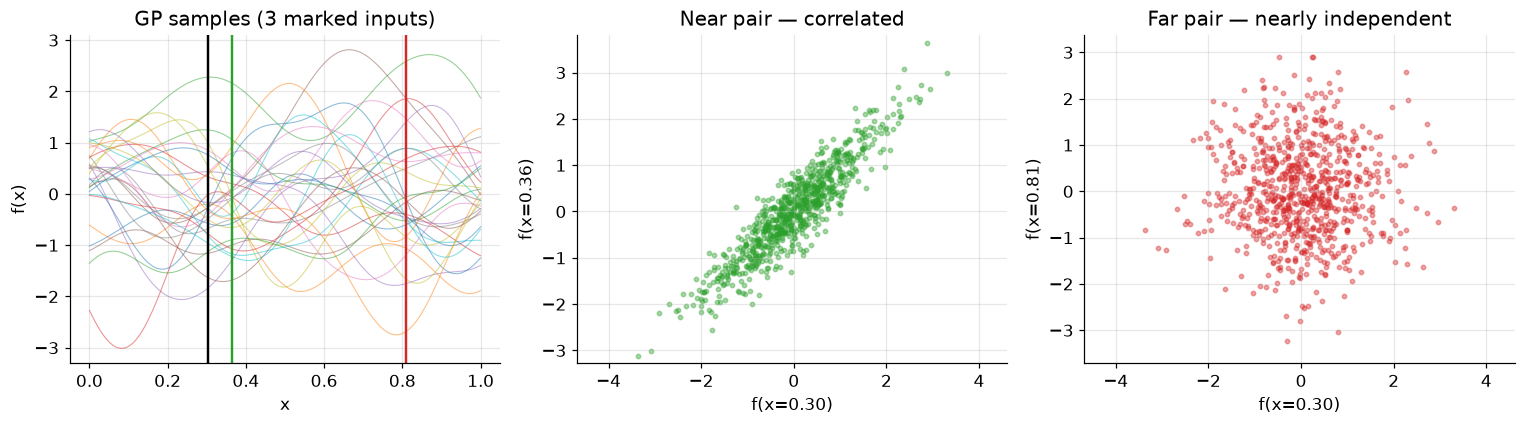

In [5]:
xs = np.linspace(0.0, 1.0, 100)
D = distance_matrix(xs[:, None], xs[:, None])
K = np.exp(-D**2 / (2 * 0.15**2)) + 1e-9 * np.eye(xs.size)
Y = rng.multivariate_normal(np.zeros(xs.size), K, 800)

a, b_near, b_far = 30, 36, 80          # reference input, a near neighbor, a far one
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for y in Y[:30]:
    ax[0].plot(xs, y, lw=0.7, alpha=0.5)
for idx, col in [(a, "k"), (b_near, "tab:green"), (b_far, "tab:red")]:
    ax[0].axvline(xs[idx], color=col, lw=1.6)
ax[0].set(title="GP samples (3 marked inputs)", xlabel="x", ylabel="f(x)")

ax[1].scatter(Y[:, a], Y[:, b_near], s=8, alpha=0.4, color="tab:green"); ax[1].axis("equal")
ax[1].set(title="Near pair — correlated", xlabel=f"f(x={xs[a]:.2f})", ylabel=f"f(x={xs[b_near]:.2f})")
ax[2].scatter(Y[:, a], Y[:, b_far], s=8, alpha=0.4, color="tab:red"); ax[2].axis("equal")
ax[2].set(title="Far pair — nearly independent", xlabel=f"f(x={xs[a]:.2f})", ylabel=f"f(x={xs[b_far]:.2f})")
plt.tight_layout(); plt.show()

## 2 · Two views: weight space and function space

::: {.callout-important}
## Where does the kernel come from?
§1 *asserted* a kernel. The function-space view *derives* it: a Gaussian prior on the weights of a linear model induces a Gaussian prior on functions, and that prior's covariance **is** the kernel.
:::

Start in *weight space*: Bayesian linear regression with a feature map $\phi(x)\in\mathbb{R}^M$:

$$f(x) = \phi(x)^\top w,\qquad w \sim \mathcal{N}(\pmb 0,\ \sigma_p^2 I).$$

(A straight line is $\phi(x)=[1, x]^\top$.) Stack inputs into a feature matrix $\Phi\in\mathbb{R}^{n\times M}$ (row $i$ is $\phi(x_i)^\top$). The function values $\pmb f = \Phi w$ are a *linear map of a Gaussian*, hence Gaussian:

$$\pmb f = \Phi w \sim \mathcal{N}\!\big(\pmb 0,\ \sigma_p^2\,\Phi\Phi^\top\big).$$

That is a GP, with covariance

$$\operatorname{cov}\!\big(f(x), f(x')\big) = \sigma_p^2\,\phi(x)^\top\phi(x') =: k(x,x').$$

- The kernel is just an *inner product of features*, which you can view as similarity in feature space.
- The weights are integrated out; from here we work directly with $k$.

A prior over weights is therefore a prior over functions. Sampling weights and mapping through $\phi$ draws GP prior samples:

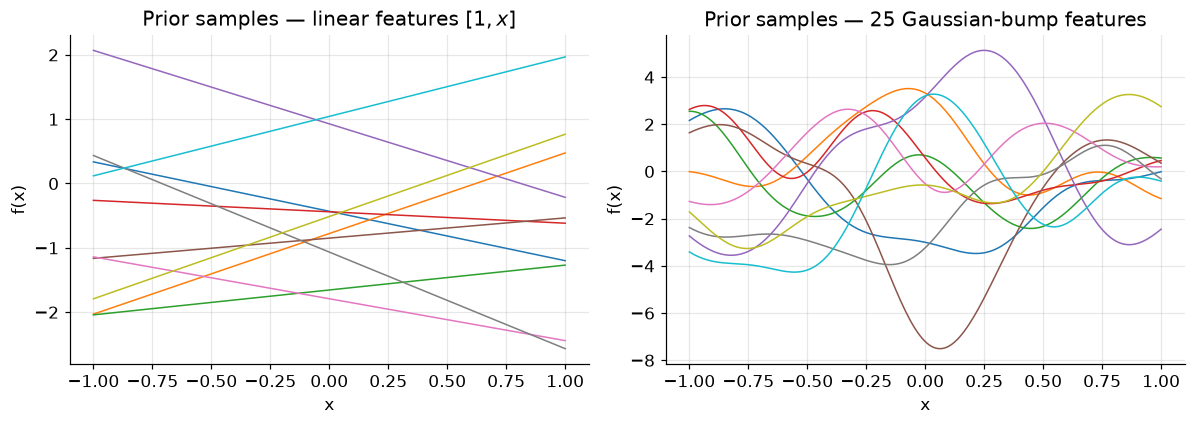

In [6]:
xs = np.linspace(-1.0, 1.0, 200)

# (a) linear features phi(x) = [1, x]  ->  samples are straight lines
Phi_lin = np.stack([np.ones_like(xs), xs], axis=1)             # (200, 2)
F_lin = Phi_lin @ rng.normal(size=(2, 10))                    # 10 prior samples, sigma_p = 1

# (b) Gaussian-bump features  ->  samples are smooth nonlinear functions
centers = np.linspace(-1.0, 1.0, 25); ell = 0.2
Phi_rbf = np.exp(-(xs[:, None] - centers[None, :])**2 / (2 * ell**2))   # (200, 25)
F_rbf = Phi_rbf @ rng.normal(size=(centers.size, 10))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(xs, F_lin, lw=1); ax[0].set(title=r"Prior samples — linear features $[1,x]$", xlabel="x", ylabel="f(x)")
ax[1].plot(xs, F_rbf, lw=1); ax[1].set(title="Prior samples — 25 Gaussian-bump features", xlabel="x", ylabel="f(x)")
plt.tight_layout(); plt.show()

- Richer functions come from richer features: polynomials $\phi=[1,x,x^2,\dots]$, Gaussian bumps, ReLUs, ...
- The *kernel trick*: we only ever need $\phi(x)^\top\phi(x')$, so we can skip $\phi$ and specify $k$ directly. The RBF kernel corresponds to *infinitely many* Gaussian features
- Though impossible to write down, trivial as a kernel.

::: {.callout-note}
## Weight space vs. function space
- For linear / GP models the two views give identical predictions; the function-space view is simpler — no $M$-dimensional weight integral, and $M$ may even be infinite.
- For neural networks they genuinely differ: the infinite-width limit of a Bayesian neural net *is* a GP (the "neural network Gaussian process").
:::

## 3 · Gaussian process regression

### Scenario
We have noisy observations of an unknown $F:\mathbb{R}^d\to\mathbb{R}$,

$$\pmb y = F(X) + \pmb\epsilon,\qquad \pmb\epsilon\sim\mathcal{N}(\pmb 0,\sigma^2 I),$$

at inputs $X=[\pmb x_1,\dots,\pmb x_N]$, and we want to predict $F$ at new inputs $X_*=[\pmb x_{*1},\dots,\pmb x_{*M}]$. (The i.i.d. noise assumption can be relaxed.)

### Joint distribution
Take a zero-mean GP prior with kernel $k$. The observed values $\pmb y$ and latent test values $\pmb f_*$ are jointly Gaussian:

$$\begin{bmatrix}\pmb y\\ \pmb f_*\end{bmatrix}\sim
\mathcal{N}\!\left(\pmb 0,\ \begin{bmatrix} K(X,X)+\sigma^2 I & K(X,X_*)\\ K(X_*,X) & K(X_*,X_*)\end{bmatrix}\right),$$

with $K(X,X_*)_{ij}=k(\pmb x_i,\pmb x_{*j})$. Note the noise $\sigma^2 I$ sits only on the observed block.

### Prediction = conditioning
Condition the test values on the observations (a standard Gaussian identity):

$$\pmb f_*\mid\pmb y \sim \mathcal{N}(\pmb m_*, P),$$
$$\pmb m_* = K(X_*,X)\,[K(X,X)+\sigma^2 I]^{-1}\pmb y,$$
$$P = K(X_*,X_*) - K(X_*,X)\,[K(X,X)+\sigma^2 I]^{-1}K(X,X_*).$$

- The mean is a smooth interpolant; $P$ gives uncertainty that grows away from the data.
- With no noise ($\sigma^2=0$) the mean passes exactly through the observations — but the solve is then less stable, hence a small jitter.

### Learning hyperparameters

Kernel hyperparameters $\theta$ (length scale, variance, noise) can be fixed by hand — useful when the GP is a prior — or learned from data by maximizing the *marginal likelihood*:

$$\log p(\pmb y\mid X,\theta) = -\tfrac12\,\pmb y^\top K_y^{-1}\pmb y \;-\; \tfrac12\log\lvert K_y\rvert \;-\; \tfrac{n}{2}\log 2\pi,
\qquad K_y = K_\theta(X,X)+\sigma^2 I.$$

- In practice one *minimizes the negative* log marginal likelihood with respect to $\theta$ (gradient-based).
- The terms trade off a data-fit $\pmb y^\top K_y^{-1}\pmb y$ against a complexity penalty $\log\lvert K_y\rvert$ — an automatic Occam's razor.

## 4 · Example: regression with scikit-learn

- [scikit-learn](https://scikit-learn.org) has a simple GP implementation; [GPyTorch](https://gpytorch.ai/) is a more flexible and scalable option.
- Below: recover $f(x)=x\sin x$ from six noisy observations with an RBF kernel, learning the hyperparameters by marginal likelihood.

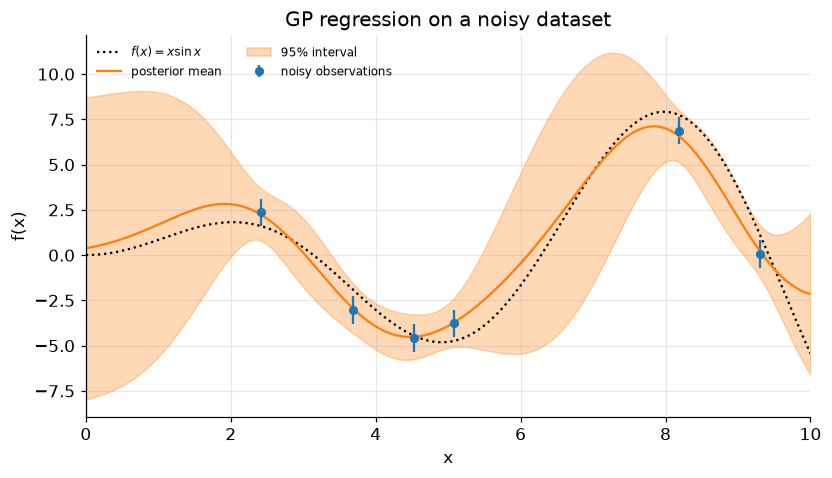

In [7]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel

X = np.linspace(0.0, 10.0, 1000).reshape(-1, 1)
y = np.squeeze(X * np.sin(X))                       # true function

obs_rng = np.random.RandomState(1)
idx = obs_rng.choice(np.arange(y.size), size=6, replace=False)
X_train, y_train = X[idx], y[idx]
noise_std = 0.75
y_train_noisy = y_train + obs_rng.normal(0.0, noise_std, size=y_train.shape)

kernel = ConstantKernel(1.0) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=noise_std**2, n_restarts_optimizer=9)
gp.fit(X_train, y_train_noisy)
mean, std = gp.predict(X, return_std=True)

plt.figure(figsize=(8.5, 4.5))
plt.plot(X, y, "k:", label=r"$f(x)=x\sin x$")
plt.errorbar(X_train.ravel(), y_train_noisy.ravel(), noise_std, fmt=".", ms=10,
             color="tab:blue", label="noisy observations")
plt.plot(X, mean, color="tab:orange", label="posterior mean")
plt.fill_between(X.ravel(), mean - 1.96 * std, mean + 1.96 * std,
                 color="tab:orange", alpha=0.3, label="95% interval")
plt.legend(fontsize=8, frameon=False, ncol=2); plt.xlim(0, 10)
plt.xlabel("x"); plt.ylabel("f(x)"); plt.title("GP regression on a noisy dataset")
plt.show()

## 5 · Kernels

The kernel encodes your assumptions about the function. A few common choices:

- *RBF / squared-exponential*: very smooth (infinitely differentiable) samples.
- *Matérn*: a smoothness parameter $\nu$; smaller $\nu$ gives rougher samples, and $\nu\to\infty$ recovers the RBF.
$$k_\nu(x,x') = \frac{1}{\Gamma(\nu)2^{\nu-1}}\Big(\tfrac{\sqrt{2\nu}}{\ell}\,d\Big)^{\nu} K_\nu\!\Big(\tfrac{\sqrt{2\nu}}{\ell}\,d\Big),\qquad d=\lVert x-x'\rVert.$$
- *Periodic* (ExpSineSquared) — for seasonal or diurnal signals.
- Kernels can be added and multiplied to combine structure; GPyTorch even supports a neural-network-parameterized kernel.

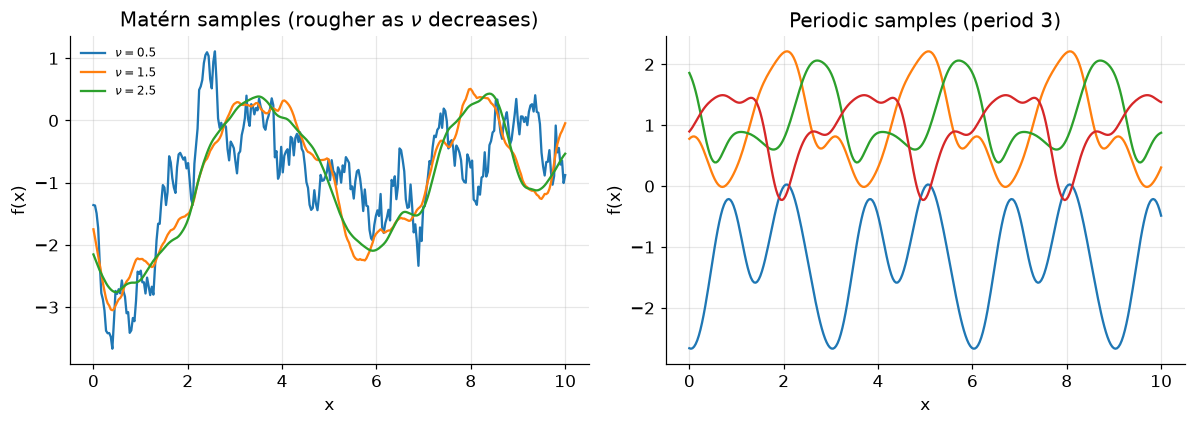

In [8]:
from sklearn.gaussian_process.kernels import Matern, ExpSineSquared

xs = np.linspace(0.0, 10.0, 300).reshape(-1, 1)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

for nu in [0.5, 1.5, 2.5]:
    gp = GaussianProcessRegressor(kernel=Matern(length_scale=1.0, nu=nu))
    ax[0].plot(xs, gp.sample_y(xs, n_samples=1, random_state=0), lw=1.5, label=rf"$\nu={nu}$")
ax[0].set(title=r"Matérn samples (rougher as $\nu$ decreases)", xlabel="x", ylabel="f(x)")
ax[0].legend(fontsize=8, frameon=False)

gp = GaussianProcessRegressor(kernel=ExpSineSquared(length_scale=1.0, periodicity=3.0))
for s in gp.sample_y(xs, n_samples=4, random_state=0).T:
    ax[1].plot(xs, s, lw=1.5)
ax[1].set(title="Periodic samples (period 3)", xlabel="x", ylabel="f(x)")
plt.tight_layout(); plt.show()

## 6 · Multiple output dimensions

- The inputs can be any dimension, as long as the output is scalar.
- For vector outputs, the simplest approach is one independent GP per output: $\pmb y = [\mathrm{GP}_1(\pmb x),\dots,\mathrm{GP}_p(\pmb x)]$.
- The curse of dimensionality applies to the *input* space — high-dimensional inputs need many points.

## 7 · Efficient inference

Cost is set by the number of training points $n$, through the linear system with $K_y = K(X,X)+\sigma^2 I$.

### Precompute once
Factor $K_y = LL^\top$ (Cholesky, $O(n^3)$ once) and solve for $\pmb\alpha = K_y^{-1}\pmb y$. The predictive mean at a test point is then a cheap dot product:

$$m(\pmb x_*) = K(\pmb x_*, X)\,\pmb\alpha.$$

### Predictive variance
$$\operatorname{var}(\pmb x_*) = \underbrace{k(\pmb x_*,\pmb x_*)}_{\text{prior}} \;-\; \underbrace{K(\pmb x_*, X)\,K_y^{-1}\,K(X,\pmb x_*)}_{\text{reduction from data}}.$$

Given the Cholesky factor, the reduction term costs $O(n^2)$ per test point (one triangular solve, then a dot product). Conditioning can only *reduce* variance — the second term is non-negative.

::: {.callout-note}
## Cholesky solves, in one line
For an SPD matrix $A=LL^\top$, solve $A\pmb x=\pmb b$ as two triangular solves: $L\pmb z=\pmb b$ (forward), then $L^\top\pmb x=\pmb z$ (back) — each $O(n^2)$. (Same back-substitution idea as the adjoints companion.)
:::

## 8 · Approximate GPs

- The $O(n^3)$ factorization makes exact GPs impractical beyond ~$10^4$ points.
- *Inducing-point* (sparse) methods summarize the data with $m\ll n$ pseudo-inputs, dropping the cost to $O(nm^2)$.
- Other routes: structured kernels (Kronecker / Toeplitz), random features, and iterative conjugate-gradient solvers (GPyTorch).

## 9 · Applications in glaciology

GPs appear wherever we need interpolation with uncertainty, a prior over functions, or a fast surrogate:

- *Interpolation* of sparsely observed fields, with calibrated error bars.
- *Priors over functions* for inverse problems (e.g. [variational inference for ice flow](https://www.sciencedirect.com/science/article/pii/S0021999122001577); more [here](https://arxiv.org/pdf/2112.13663)).
- *Emulation* of expensive simulators (e.g. [Edwards et al. 2021](https://research-repository.st-andrews.ac.uk/bitstream/handle/10023/24263/Edwards_2021_Nature_Projectedlandice_AAM.pdf?sequence=1&isAllowed=y); ice-sheet reconstruction at [125 ka](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2019JF005237)).
- Emulation is usually paired with dimensionality reduction (e.g. PCA) to handle spatial / temporal outputs.

### Example 1 — emulating a subglacial hydrology model

[Hill et al. (2024)](https://essopenarchive.org/users/832963/articles/1226265-computationally-efficient-subglacial-drainage-modeling-using-gaussian-process-emulators-glads-gp-v1-0?commit=d091d843a1a3fc443c8b310c9f4c098c6656e12e) build a GP emulator for the GlaDS subglacial hydrology model, for Bayesian inference of unknown parameters:

- Sample parameter sets and run a GlaDS simulation for each (the training data).
- Reduce the spatio-temporal outputs to their principal components (PCA).
- Train a GP mapping parameters → PC coefficients, reconstructing full fields for new parameters.
- A fixed PCA basis with a learned weight map — note the parallel to a DeepONet.

<div>
<img src="https://github.com/glamacles/notebooks/blob/main/images/Screenshot 2025-06-20 224428.png?raw=1" width="700"/>
</div>

### Example 2 — calving dynamics at Helheim Glacier

[Downs et al. (2022)](https://www.cambridge.org/core/journals/journal-of-glaciology/article/inferring-timedependent-calving-dynamics-at-helheim-glacier/D678DCC319C0228A087701B315E4C971) use a GP emulator to infer uncertain model parameters for Helheim Glacier:

- Run an ensemble of model simulations across parameter values.
- Train a GP on the ensemble to predict model–observation mismatch for any parameters.
- The GP fills the gaps between sampled parameters, enabling fast MCMC sampling that would otherwise be intractable.

<div>
<img src="https://github.com/glamacles/notebooks/blob/main/images/gaussian_processes/emulator.png?raw=1" width="700"/>
</div>